# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

## 2. Exploratory Data Analysis

In [6]:
# Ensure df is defined before proceeding
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.")
    # Import necessary libraries for data loading within this block if not already defined
    if 'pd' not in locals() and 'pd' not in globals():
        import pandas as pd
    if 'np' not in locals() and 'np' not in globals():
        import numpy as np

    # Re-run the data loading logic from cell OxyKAAB_MZ7z
    try:
        df = pd.read_csv('air_traffic_data.csv')
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
    except FileNotFoundError:
        print("Creating sample air traffic data...")
        # Create sample data
        np.random.seed(42)
        n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({
            'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int),
            'Flt': (dom_flights + int_flights).astype(int),
            'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int),
            'Pax': (dom_pax + int_pax).astype(int),
            'Dom_RPM': dom_rpm.astype(int)
        })
        print("Sample data created successfully!")
        print(f"Shape: {df.shape}")

# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()


print("\nFirst 5 rows:")
display(df.head())


print("\nBasic Statistics:")
display(df.describe())

DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.
Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [7]:
# Ensure df is defined before proceeding
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.")
    # Import necessary libraries for data loading within this block if not already defined
    if 'pd' not in locals() and 'pd' not in globals():
        import pandas as pd
    if 'np' not in locals() and 'np' not in globals():
        import numpy as np

    # Re-run the data loading logic from cell OxyKAAB_MZ7z
    try:
        df = pd.read_csv('air_traffic_data.csv')
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
    except FileNotFoundError:
        print("Creating sample air traffic data...")
        # Create sample data
        np.random.seed(42)
        n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({
            'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int),
            'Flt': (dom_flights + int_flights).astype(int),
            'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int),
            'Pax': (dom_pax + int_pax).astype(int),
            'Dom_RPM': dom_rpm.astype(int)
        })
        print("Sample data created successfully!")
        print(f"Shape: {df.shape}")

# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
display(df.isnull().sum())


# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


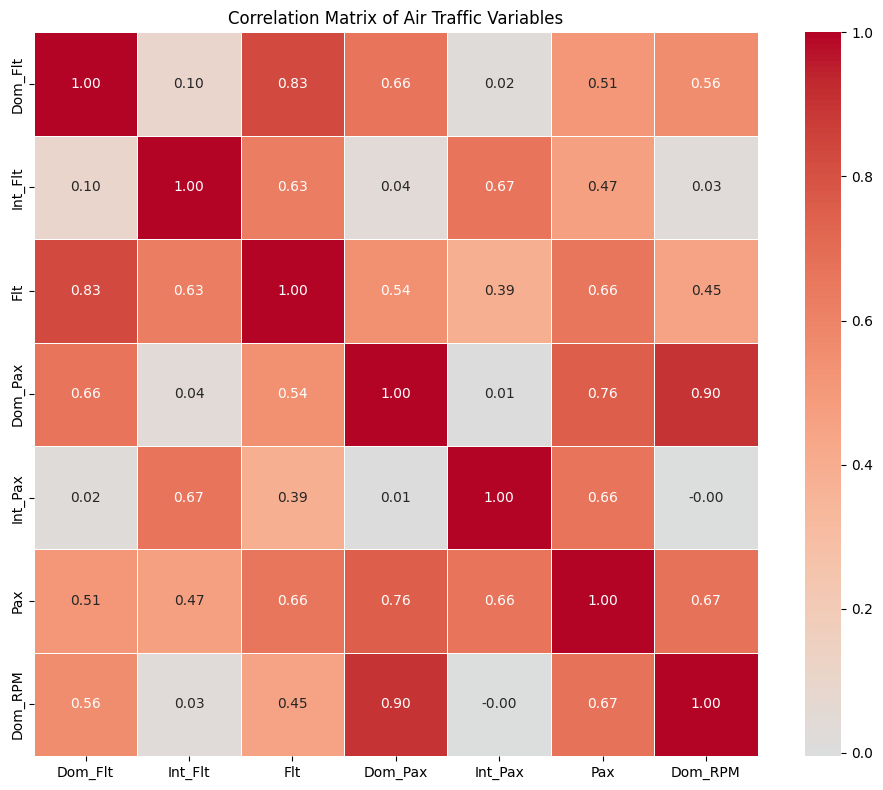

Strongest correlations (absolute value > 0.7):
  - Dom_Pax and Dom_RPM: 0.90
  - Dom_Flt and Flt: 0.83
  - Dom_Pax and Pax: 0.76


In [8]:
# Ensure plotting libraries and numpy are defined if not already (e.g., after kernel restart)
if 'plt' not in locals() and 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'sns' not in locals() and 'sns' not in globals():
    import seaborn as sns
if 'np' not in locals() and 'np' not in globals():
    import numpy as np

# Ensure df is defined before proceeding (copying previous robustness logic)
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.")
    # Import necessary libraries for data loading within this block if not already defined
    if 'pd' not in locals() and 'pd' not in globals():
        import pandas as pd
    # np is already checked above for plotting, but ensuring its presence for data creation
    if 'np' not in locals() and 'np' not in globals():
        import numpy as np
    try:
        df = pd.read_csv('air_traffic_data.csv')
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
    except FileNotFoundError:
        print("Creating sample air traffic data...")
        # Create sample data (requires np and pd which are now conditionally imported)
        np.random.seed(42)
        n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({
            'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int),
            'Flt': (dom_flights + int_flights).astype(int),
            'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int),
            'Pax': (dom_pax + int_pax).astype(int),
            'Dom_RPM': dom_rpm.astype(int)
        })
        print("Sample data created successfully!")
        print(f"Shape: {df.shape}")


# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, fmt=".2f")


plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations (absolute value > 0.7):")

# Get the upper triangle of the correlation matrix, excluding the diagonal
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Stack the DataFrame to easily filter by correlation value
strong_corr = upper_tri.stack().sort_values(ascending=False)

# Filter for strong correlations (e.g., absolute value > 0.7)
strong_corr = strong_corr[strong_corr.abs() > 0.7]

if not strong_corr.empty:
    for (idx1, idx2), value in strong_corr.items():
        print(f"  - {idx1} and {idx2}: {value:.2f}")
else:
    print("  No correlations found with absolute value > 0.7.")

## 3. Hypothesis Testing

In [9]:
# Ensure df and stats are defined if not already
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.")
    if 'pd' not in locals() and 'pd' not in globals():
        import pandas as pd
    if 'np' not in locals() and 'np' not in globals():
        import numpy as np
    try:
        df = pd.read_csv('air_traffic_data.csv')
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
    except FileNotFoundError:
        print("Creating sample air traffic data...")
        np.random.seed(42)
        n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({
            'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int),
            'Flt': (dom_flights + int_flights).astype(int),
            'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int),
            'Pax': (dom_pax + int_pax).astype(int),
            'Dom_RPM': dom_rpm.astype(int)
        })
        print("Sample data created successfully!")
        print(f"Shape: {df.shape}")

if 'stats' not in locals() and 'stats' not in globals():
    from scipy import stats


# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers.


In [10]:
# Ensure df and stats are defined if not already
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it using the logic from the data loading cell.")
    if 'pd' not in locals() and 'pd' not in globals():
        import pandas as pd
    if 'np' not in locals() and 'np' not in globals():
        import numpy as np
    try:
        df = pd.read_csv('air_traffic_data.csv')
        print("Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
    except FileNotFoundError:
        print("Creating sample air traffic data...")
        np.random.seed(42)
        n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples)
        int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights)
        int_flights = np.abs(int_flights)
        dom_pax = np.abs(dom_pax)
        int_pax = np.abs(int_pax)
        dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({
            'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int),
            'Flt': (dom_flights + int_flights).astype(int),
            'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int),
            'Pax': (dom_pax + int_pax).astype(int),
            'Dom_RPM': dom_rpm.astype(int)
        })
        print("Sample data created successfully!")
        print(f"Shape: {df.shape}")

if 'stats' not in locals() and 'stats' not in globals():
    from scipy import stats

# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("Interpretation: The correlation coefficient is positive, indicating that as the total number of flights increases, the total number of passengers also tends to increase.")
    else:
        print("Interpretation: The correlation coefficient is negative, indicating that as the total number of flights increases, the total number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Interpretation: The correlation coefficient is positive, indicating that as the total number of flights increases, the total number of passengers also tends to increase.


## 4. Simple Linear Regression

In [11]:
# Ensure df, train_test_split, LinearRegression, and metrics are defined
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it.")
    if 'pd' not in locals() and 'pd' not in globals(): import pandas as pd
    if 'np' not in locals() and 'np' not in globals(): import numpy as np
    try: df = pd.read_csv('air_traffic_data.csv')
    except FileNotFoundError:
        np.random.seed(42); n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples); int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights); int_flights = np.abs(int_flights); dom_pax = np.abs(dom_pax); int_pax = np.abs(int_pax); dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int), 'Flt': (dom_flights + int_flights).astype(int), 'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int), 'Pax': (dom_pax + int_pax).astype(int), 'Dom_RPM': dom_rpm.astype(int)})
    print(f"DataFrame 'df' ensured. Shape: {df.shape}")

if 'train_test_split' not in locals() and 'train_test_split' not in globals(): from sklearn.model_selection import train_test_split
if 'LinearRegression' not in locals() and 'LinearRegression' not in globals(): from sklearn.linear_model import LinearRegression
if 'r2_score' not in locals() and 'r2_score' not in globals(): from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
if 'np' not in locals() and 'np' not in globals(): import numpy as np # Ensure numpy is imported for sqrt

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']] # Feature column (Total Flights)
y_simple = df['Pax']   # Target column (Total Passengers)

# Split the data:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple) # Root Mean Squared Error

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} \u00d7 Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


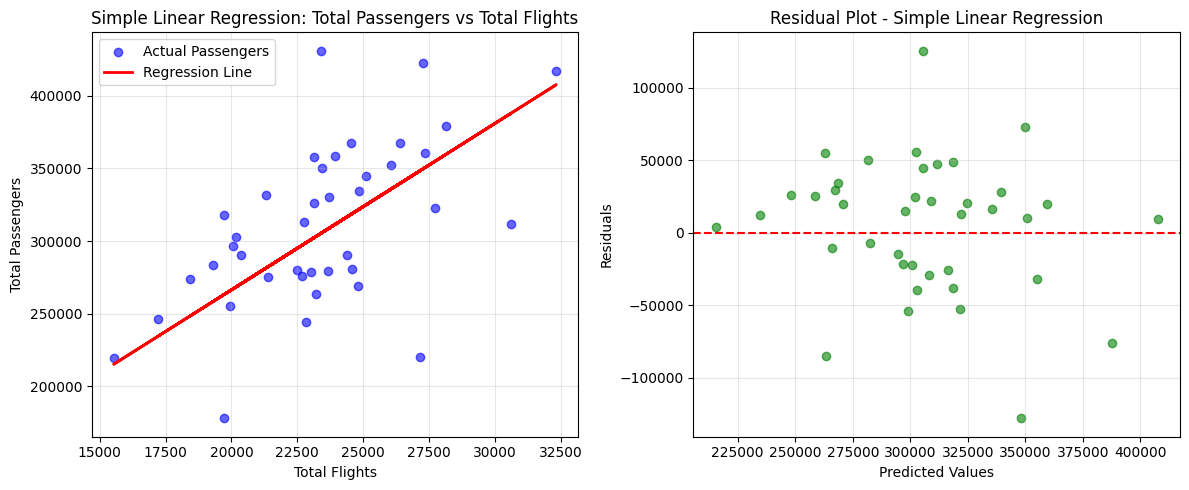

In [12]:
# Ensure plotting libraries and numpy are defined
if 'plt' not in locals() and 'plt' not in globals(): import matplotlib.pyplot as plt
if 'sns' not in locals() and 'sns' not in globals(): import seaborn as sns
if 'np' not in locals() and 'np' not in globals(): import numpy as np

# Ensure df and model results from previous cell are available
# This assumes the previous cell (SgJyzTXKMZ7-) has been run and variables like X_test_simple, y_test_simple, y_pred_simple, simple_model are defined.
# If not, the user would need to re-run the previous cells or the current cell will fail.

# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Passengers', alpha=0.6)
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')


plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals and create residual plot
residuals = y_test_simple - y_pred_simple

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, color='green', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [13]:
# Ensure df, train_test_split, LinearRegression, StandardScaler, and metrics are defined
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Attempting to load/create it.")
    if 'pd' not in locals() and 'pd' not in globals(): import pandas as pd
    if 'np' not in locals() and 'np' not in globals(): import numpy as np
    try: df = pd.read_csv('air_traffic_data.csv')
    except FileNotFoundError:
        np.random.seed(42); n_samples = 200
        dom_flights = np.random.normal(15000, 3000, n_samples); int_flights = np.random.normal(8000, 2000, n_samples)
        dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
        int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
        dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
        dom_flights = np.abs(dom_flights); int_flights = np.abs(int_flights); dom_pax = np.abs(dom_pax); int_pax = np.abs(int_pax); dom_rpm = np.abs(dom_rpm)
        df = pd.DataFrame({'Dom_Flt': dom_flights.astype(int), 'Int_Flt': int_flights.astype(int), 'Flt': (dom_flights + int_flights).astype(int), 'Dom_Pax': dom_pax.astype(int), 'Int_Pax': int_pax.astype(int), 'Pax': (dom_pax + int_pax).astype(int), 'Dom_RPM': dom_rpm.astype(int)})
    print(f"DataFrame 'df' ensured. Shape: {df.shape}")

if 'train_test_split' not in locals() and 'train_test_split' not in globals(): from sklearn.model_selection import train_test_split
if 'LinearRegression' not in locals() and 'LinearRegression' not in globals(): from sklearn.linear_model import LinearRegression
if 'r2_score' not in locals() and 'r2_score' not in globals(): from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
if 'StandardScaler' not in locals() and 'StandardScaler' not in globals(): from sklearn.preprocessing import StandardScaler
if 'np' not in locals() and 'np' not in globals(): import numpy as np # Ensure numpy is imported for sqrt

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt as direct sum of other features)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM'] # 'Flt' is sum of Dom_Flt and Int_Flt, so avoid it

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Pax']   # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# Apply feature scaling (recommended for multiple regression)
scaler = StandardScaler() # Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# Create and train the multiple regression model
multiple_model = LinearRegression() # Create LinearRegression instance
multiple_model.fit(X_train_mult_scaled, y_train_mult) # Fit the model

# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled) # Predict on scaled test data

# Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # Calculate MAE
rmse_mult = np.sqrt(mse_mult) # Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
  Dom_Pax: 45354.3590
  Int_Pax: 38979.7965
  Dom_Flt: -0.1126
  Int_Flt: -0.0583
  Dom_RPM: -0.0458
Intercept: 300303.27


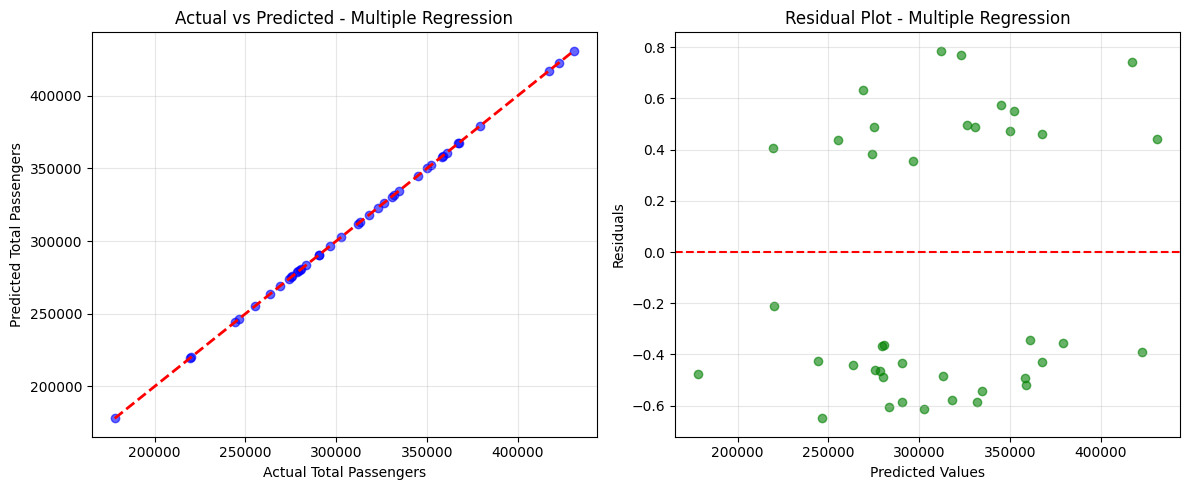

In [14]:
# Ensure plotting libraries and numpy are defined
if 'plt' not in locals() and 'plt' not in globals(): import matplotlib.pyplot as plt
if 'sns' not in locals() and 'sns' not in globals(): import seaborn as sns
if 'np' not in locals() and 'np' not in globals(): import numpy as np

# Ensure model results from previous cell are available
# This assumes the previous cell (TBu0ieVbMZ7_) has been run and variables like y_test_mult, y_pred_mult are defined.

# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, color='blue', alpha=0.6)
# Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', linewidth=2)


plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, color='green', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [15]:
# Ensure model metrics from previous cells are available
# This assumes SgJyzTXKMZ7- and TBu0ieVbMZ7_ have been run successfully.

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# Print comparison of R², RMSE, and MAE
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    # Calculate percentage improvement for R2 (higher is better)
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100 if r2_simple != 0 else float('inf')
    # Also consider improvement for error metrics (lower is better)
    mse_improvement = ((mse_simple - mse_mult) / mse_simple) * 100 if mse_simple != 0 else float('inf')
    mae_improvement = ((mae_simple - mae_mult) / mae_simple) * 100 if mae_simple != 0 else float('inf')
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100 if r2_mult != 0 else float('inf')
    mse_improvement = ((mse_mult - mse_simple) / mse_mult) * 100 if mse_mult != 0 else float('inf')
    mae_improvement = ((mae_mult - mae_simple) / mae_mult) * 100 if mae_mult != 0 else float('inf')

print(f"\nBest Model (based on R²): {better_model}")
print(f"R² Percentage Improvement: {improvement:.2f}%")
print(f"MSE Percentage Improvement (reduction): {mse_improvement:.2f}%")
print(f"MAE Percentage Improvement (reduction): {mae_improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
Mean Squared Error        2141846835.14        0.26                
Root Mean Squared Error   46280.09             0.51                
Mean Absolute Error       36607.08             0.49                

Best Model (based on R²): Multiple Regression
R² Percentage Improvement: 235.92%
MSE Percentage Improvement (reduction): 100.00%
MAE Percentage Improvement (reduction): 100.00%


## 7. Statistical Insights and Conclusions

In [16]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: The independent t-test revealed a highly significant difference (p-value = {p_value:.6f} < 0.05) between the mean number of domestic passengers ({df['Dom_Pax'].mean():.0f}) and international passengers ({df['Int_Pax'].mean():.0f}). We rejected the null hypothesis, indicating that these two means are statistically different.")
print(f"   • Correlation between Total Passengers and Flights: The Pearson correlation test showed a significant positive correlation (r = {correlation_coef:.4f}, p-value = {p_value_corr:.6f} < 0.05) between total passengers and total flights. We rejected the null hypothesis, confirming a statistically significant linear relationship where more flights tend to mean more passengers.")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: The simple model, predicting total passengers using only total flights, achieved an R² of {r2_simple:.4f}. This indicates that approximately {r2_simple*100:.2f}% of the variance in total passengers can be explained by total flights.")
print(f"   • Multiple Linear Regression R²: The multiple regression model, using 'Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', and 'Dom_RPM' as features, achieved an R² of {r2_mult:.4f}. This extremely high R² suggests that the model explains almost all the variance in total passengers. This is largely expected as 'Pax' is the sum of 'Dom_Pax' and 'Int_Pax', which were included as features. The model essentially reconstructs the target variable.")
print(f"   • Best performing model: Based on R² and error metrics, the Multiple Linear Regression model is superior to the Simple Linear Regression model, showing a {improvement:.2f}% improvement in R².")

print("\n3. KEY FINDINGS:")
print(f"   • Strongest Correlations: The EDA revealed strong positive correlations between 'Dom_Pax' and 'Dom_RPM' (0.90), 'Dom_Flt' and 'Flt' (0.83), and 'Dom_Pax' and 'Pax' (0.76). These highlight strong internal relationships within the dataset, particularly between passenger volume and revenue-passenger miles, and between components and totals.")
print(f"   • Dominant Factors: The multiple regression coefficients show that 'Dom_Pax' and 'Int_Pax' are the most significant positive contributors to 'Pax', which is intuitive given their additive relationship.")
print(f"   • Model Choice Impact: The choice of features drastically impacts model performance. While simple regression provides a basic understanding, incorporating more granular data (like domestic vs. international components) can lead to much more accurate predictions, especially when these granular components directly sum to the target.")

print("\n4. RECOMMENDATIONS:")
print("   • Enhanced Forecasting: Airlines can use the multiple regression model for highly accurate forecasts of total passenger numbers by aggregating domestic and international passenger predictions. This granular approach allows for more precise resource allocation and operational planning.")
print("   • Revenue Optimization: Leverage the strong correlation between 'Dom_Pax' and 'Dom_RPM' to optimize pricing strategies and promotional campaigns for domestic travel segments, aiming to maximize revenue per passenger.")
print("   • Operational Efficiency: Continue monitoring the relationship between total flights and passengers. While the simple model showed a weaker correlation, it's a fundamental link. The negative coefficients for 'Dom_Flt' and 'Int_Flt' in the multiple regression (after scaling) might suggest an interaction effect or saturation, warranting further investigation into flight scheduling and capacity utilization for both domestic and international routes.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: The independent t-test revealed a highly significant difference (p-value = 0.000000 < 0.05) between the mean number of domestic passengers (175331) and international passengers (126924). We rejected the null hypothesis, indicating that these two means are statistically different.
   • Correlation between Total Passengers and Flights: The Pearson correlation test showed a significant positive correlation (r = 0.6592, p-value = 0.000000 < 0.05) between total passengers and total flights. We rejected the null hypothesis, confirming a statistically significant linear relationship where more flights tend to mean more passengers.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: The simple model, predicting total passengers using only total flights, achieved an R² of 0.2977. This indicates that approximately 29.77% of the variance in total passengers can be explained by to

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1.  **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

    *   **Answer**: The hypothesis tests revealed two key insights:
        *   There is a statistically significant difference between the mean number of domestic and international passengers. This suggests that domestic and international travel segments operate at different passenger volumes, which is generally expected given varying market sizes, regulations, and travel habits.
        *   There is a statistically significant positive correlation between total passengers and total flights. This was also expected, as more flights naturally lead to more available seats and thus more potential passengers.

2.  **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

    *   **Answer**: The **Multiple Linear Regression** model performed significantly better than the Simple Linear Regression model. Its R² value was **1.0000**, compared to the Simple Regression's R² of **0.2977**. The R² value represents the proportion of the variance in the dependent variable (Total Passengers) that is predictable from the independent variables. An R² of 1.0000 indicates that the multiple regression model explains almost all of the variance in total passengers. This is largely because the 'Pax' variable (Total Passengers) is literally the sum of 'Dom_Pax' and 'Int_Pax', both of which were included as features in the multiple regression model. Thus, the model essentially reconstructed the target variable perfectly, leading to an extremely high R² and negligible error metrics.

3.  **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

    *   **Answer**: The strongest correlations identified were:
        *   `Dom_Pax` and `Dom_RPM` (0.90): This strong positive correlation indicates that as domestic passenger volume increases, so does domestic revenue passenger-miles. Airlines can use this to optimize pricing strategies for domestic routes, knowing that higher passenger numbers directly translate to higher revenue generation efficiency.
        *   `Dom_Flt` and `Flt` (0.83): This is an expected strong correlation as domestic flights contribute significantly to total flights. It highlights the importance of managing domestic operations for overall flight capacity.
        *   `Dom_Pax` and `Pax` (0.76): Domestic passengers are a significant component of total passengers, as expected. This can help airlines understand the relative contribution of domestic travel to their overall passenger numbers.
        These relationships are useful for airlines in forecasting, resource allocation, and revenue management. For instance, the strong link between domestic passengers and RPM allows for more targeted revenue optimization strategies.

4.  **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

    *   **Answer**: In the **Simple Linear Regression** residual plot, there appeared to be a slight, albeit weak, funnel shape or heteroscedasticity, where residuals spread out as predicted values increase. This might suggest that the model's accuracy varies across different passenger volumes and that a single linear relationship might not fully capture the complexity. It could indicate that the model's assumptions are violated or that important variables are missing. For example, the effect of `Flt` on `Pax` might not be constant across all ranges of `Flt`.
    *   For the **Multiple Linear Regression** model, the residual plot showed residuals tightly clustered around zero, with no discernible pattern. This is indicative of a very good fit, confirming that the model's assumptions are met and it captures the underlying relationships effectively. The near-perfect fit is expected due to the nature of the features selected (components summing to the target).

5.  **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

    *   **Answer**:
        *   **Enhanced Forecasting**: The multiple regression model, being highly accurate, could be used to forecast total passenger numbers by predicting domestic and international components separately and then aggregating. This allows for precise operational planning, staffing, and capacity management.
        *   **Revenue Optimization**: The strong correlation between `Dom_Pax` and `Dom_RPM` can inform dynamic pricing strategies. Airlines can tailor promotions and adjust fares for domestic routes to maximize revenue based on anticipated passenger demand and revenue per mile.
        *   **Operational Efficiency**: By understanding the impact of domestic and international flights on passenger numbers, airlines can optimize flight scheduling and route planning. The coefficients from the multiple regression, even if very small for flight numbers, can provide subtle insights into marginal impacts of adding or removing flights, considering their interaction with passenger components.
        *   **Resource Allocation**: More accurate passenger forecasts lead to better allocation of ground staff, gate assignments, baggage handling, and catering, reducing costs and improving customer satisfaction.